In [1]:
#Cell 1: Import Libraries:

# ============================================================
# 🏠 REAL ESTATE PRICE PREDICTOR
# Boston Housing Dataset
# Built by: Kartik | Munich | 2025
# Goal: Predict house prices using ML Regression
# ============================================================

#Core libraries:
import numpy as np 
import pandas as pd

#Visualisation:
import matplotlib.pyplot as plt 
import seaborn as sns 

#Machine Learning:
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor 

#Settiings:
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

print("✅ All libraries imported successfully!")
print("🏠 Real Estate Predictor is ready!") 

✅ All libraries imported successfully!
🏠 Real Estate Predictor is ready!


In [3]:
# ============================================================
# CELL 2: Load the Boston Housing Dataset (FIXED)
# ============================================================

# This dataset uses spaces as separator, not commas!
df = pd.read_csv('housing.csv', sep='\s+', header=None)

# Add proper column names
df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
              'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# First look
print("🏠 BOSTON HOUSING DATASET")
print("=" * 50)
print(f"📊 Total houses:   {df.shape[0]}")
print(f"📋 Total features: {df.shape[1]}")
print("=" * 50)

# Explain each column
print("\n📋 WHAT EACH COLUMN MEANS:")
columns_explained = {
    'CRIM'   : 'Crime rate per capita in the area',
    'ZN'     : 'Proportion of residential land zoned',
    'INDUS'  : 'Proportion of industrial business acres',
    'CHAS'   : 'Near Charles River? (1=Yes, 0=No)',
    'NOX'    : 'Air pollution level (nitric oxide)',
    'RM'     : 'Average number of rooms per house',
    'AGE'    : 'Proportion of old houses built before 1940',
    'DIS'    : 'Distance to employment centres',
    'RAD'    : 'Accessibility to highways',
    'TAX'    : 'Property tax rate',
    'PTRATIO': 'Pupil-teacher ratio in area schools',
    'B'      : 'Proportion of Black residents',
    'LSTAT'  : '% of lower status population',
    'MEDV'   : '🎯 MEDIAN HOUSE VALUE ($1000s) ← TARGET!'
}

for col, meaning in columns_explained.items():
    print(f"   {col:8} → {meaning}")

print("\n🔍 First 5 rows:")
print(df.head())

print("\n📊 Basic Statistics:")
print(df.describe().round(2))

🏠 BOSTON HOUSING DATASET
📊 Total houses:   506
📋 Total features: 14

📋 WHAT EACH COLUMN MEANS:
   CRIM     → Crime rate per capita in the area
   ZN       → Proportion of residential land zoned
   INDUS    → Proportion of industrial business acres
   CHAS     → Near Charles River? (1=Yes, 0=No)
   NOX      → Air pollution level (nitric oxide)
   RM       → Average number of rooms per house
   AGE      → Proportion of old houses built before 1940
   DIS      → Distance to employment centres
   RAD      → Accessibility to highways
   TAX      → Property tax rate
   PTRATIO  → Pupil-teacher ratio in area schools
   B        → Proportion of Black residents
   LSTAT    → % of lower status population
   MEDV     → 🎯 MEDIAN HOUSE VALUE ($1000s) ← TARGET!

🔍 First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.0

🎯 TARGET: MEDV (Median House Value in $1000s)
   Minimum Price:  $5,000
   Maximum Price:  $50,000
   Average Price:  $22,533
   Median Price:   $21,200


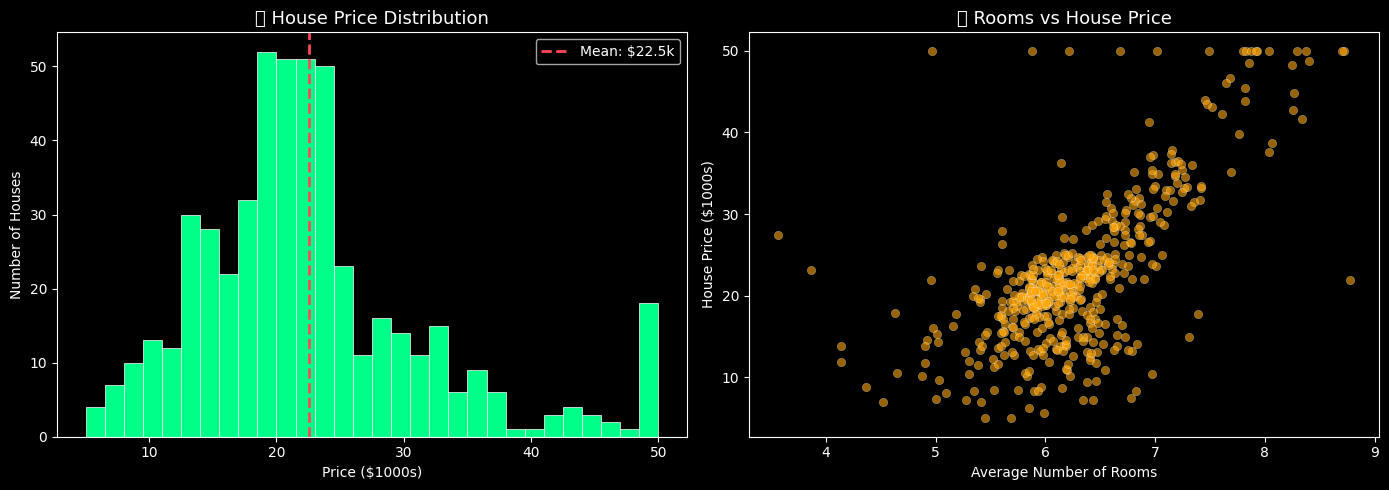


📊 CORRELATION WITH HOUSE PRICE:
(How much each feature affects the price)
   RM       +0.695  ↑ increases price  ████████████████████
   ZN       +0.360  ↑ increases price  ██████████
   B        +0.333  ↑ increases price  ██████████
   DIS      +0.250  ↑ increases price  ███████
   CHAS     +0.175  ↑ increases price  █████
   AGE      -0.377  ↓ decreases price  ███████████
   RAD      -0.382  ↓ decreases price  ███████████
   CRIM     -0.388  ↓ decreases price  ███████████
   NOX      -0.427  ↓ decreases price  ████████████
   TAX      -0.469  ↓ decreases price  ██████████████
   INDUS    -0.484  ↓ decreases price  ██████████████
   PTRATIO  -0.508  ↓ decreases price  ███████████████
   LSTAT    -0.738  ↓ decreases price  ██████████████████████


In [6]:
# ============================================================
# CELL 3: Explore the Target — House Prices
# ============================================================

print("🎯 TARGET: MEDV (Median House Value in $1000s)")
print("=" * 50)
print(f"   Minimum Price:  ${df['MEDV'].min()*1000:,.0f}")
print(f"   Maximum Price:  ${df['MEDV'].max()*1000:,.0f}")
print(f"   Average Price:  ${df['MEDV'].mean()*1000:,.0f}")
print(f"   Median Price:   ${df['MEDV'].median()*1000:,.0f}")
print("=" * 50)

# Visualise price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Price Distribution
axes[0].hist(df['MEDV'], bins=30, color='#00ff88',
             edgecolor='white', linewidth=0.5)
axes[0].set_title('🏠 House Price Distribution', fontsize=13)
axes[0].set_xlabel('Price ($1000s)')
axes[0].set_ylabel('Number of Houses')
axes[0].axvline(df['MEDV'].mean(), color='#ff4757',
                linestyle='--', linewidth=2, label=f"Mean: ${df['MEDV'].mean():.1f}k")
axes[0].legend()

# Plot 2 - Rooms vs Price
axes[1].scatter(df['RM'], df['MEDV'],
                alpha=0.6, color='#ffa502', edgecolor='white', linewidth=0.3)
axes[1].set_title('🏠 Rooms vs House Price', fontsize=13)
axes[1].set_xlabel('Average Number of Rooms')
axes[1].set_ylabel('House Price ($1000s)')

plt.tight_layout()
plt.show()

# Most correlated features with price
print("\n📊 CORRELATION WITH HOUSE PRICE:")
print("(How much each feature affects the price)")
print("=" * 50)
correlations = df.corr()['MEDV'].sort_values(ascending=False)
for col, corr in correlations.items():
    if col != 'MEDV':
        bar = '█' * int(abs(corr) * 30)
        direction = '↑ increases' if corr > 0 else '↓ decreases'
        print(f"   {col:8} {corr:+.3f}  {direction} price  {bar}")

In [8]:
# ============================================================
# CELL 4: Prepare Data for ML
# ============================================================

# Separate features and target
X = df.drop('MEDV', axis=1)   # All columns except price
y = df['MEDV']                 # House price — what we predict

print("📊 DATA PREPARATION:")
print("=" * 50)
print(f"   Features (X): {X.shape}")
print(f"   Target   (y): {y.shape}")

# Check missing values
print(f"\n🔍 Missing values: {X.isnull().sum().sum()}")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\n✂️  TRAIN/TEST SPLIT:")
print(f"   Training houses: {X_train.shape[0]}")
print(f"   Testing houses:  {X_test.shape[0]}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✅ Features scaled!")
print(f"   Mean: {X_train_scaled.mean():.6f}  (should be ~0)")
print(f"   Std:  {X_train_scaled.std():.6f}   (should be ~1)")
print("\n🚀 Data ready for ML!")

📊 DATA PREPARATION:
   Features (X): (506, 13)
   Target   (y): (506,)

🔍 Missing values: 0

✂️  TRAIN/TEST SPLIT:
   Training houses: 404
   Testing houses:  102

✅ Features scaled!
   Mean: -0.000000  (should be ~0)
   Std:  1.000000   (should be ~1)

🚀 Data ready for ML!


In [9]:
# ============================================================
# CELL 5: Train & Compare Regression Models
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Define models
models = {
    'Linear Regression'    : LinearRegression(),
    'Polynomial Regression': Pipeline([
        ('poly',   PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ]),
    'Decision Tree'        : DecisionTreeRegressor(max_depth=5, random_state=42),
}

results = {}

print("🚀 TRAINING REGRESSION MODELS...")
print("=" * 60)

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Metrics
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    cv   = cross_val_score(model, X_train_scaled, y_train,
                           cv=5, scoring='r2')

    results[name] = {
        'r2'    : r2,
        'mae'   : mae,
        'rmse'  : rmse,
        'cv_r2' : cv.mean(),
        'cv_std': cv.std(),
        'y_pred': y_pred
    }

    print(f"\n🏠 {name}")
    print(f"   R² Score:       {r2:.4f}  ({r2*100:.1f}% variance explained)")
    print(f"   MAE:            ${mae*1000:,.0f} average error")
    print(f"   RMSE:           ${rmse*1000:,.0f} root mean squared error")
    print(f"   Cross-Val R²:   {cv.mean():.3f} ± {cv.std():.3f}")

print("\n" + "=" * 60)

# Best model
best = max(results, key=lambda x: results[x]['r2'])
print(f"\n🏆 BEST MODEL: {best}")
print(f"   R² Score: {results[best]['r2']:.4f}")
print(f"   This model explains {results[best]['r2']*100:.1f}% of house price variance!")

🚀 TRAINING REGRESSION MODELS...

🏠 Linear Regression
   R² Score:       0.6688  (66.9% variance explained)
   MAE:            $3,189 average error
   RMSE:           $4,929 root mean squared error
   Cross-Val R²:   0.724 ± 0.064

🏠 Polynomial Regression
   R² Score:       0.8056  (80.6% variance explained)
   MAE:            $2,575 average error
   RMSE:           $3,776 root mean squared error
   Cross-Val R²:   0.781 ± 0.065

🏠 Decision Tree
   R² Score:       0.8834  (88.3% variance explained)
   MAE:            $2,308 average error
   RMSE:           $2,925 root mean squared error
   Cross-Val R²:   0.658 ± 0.077


🏆 BEST MODEL: Decision Tree
   R² Score: 0.8834
   This model explains 88.3% of house price variance!


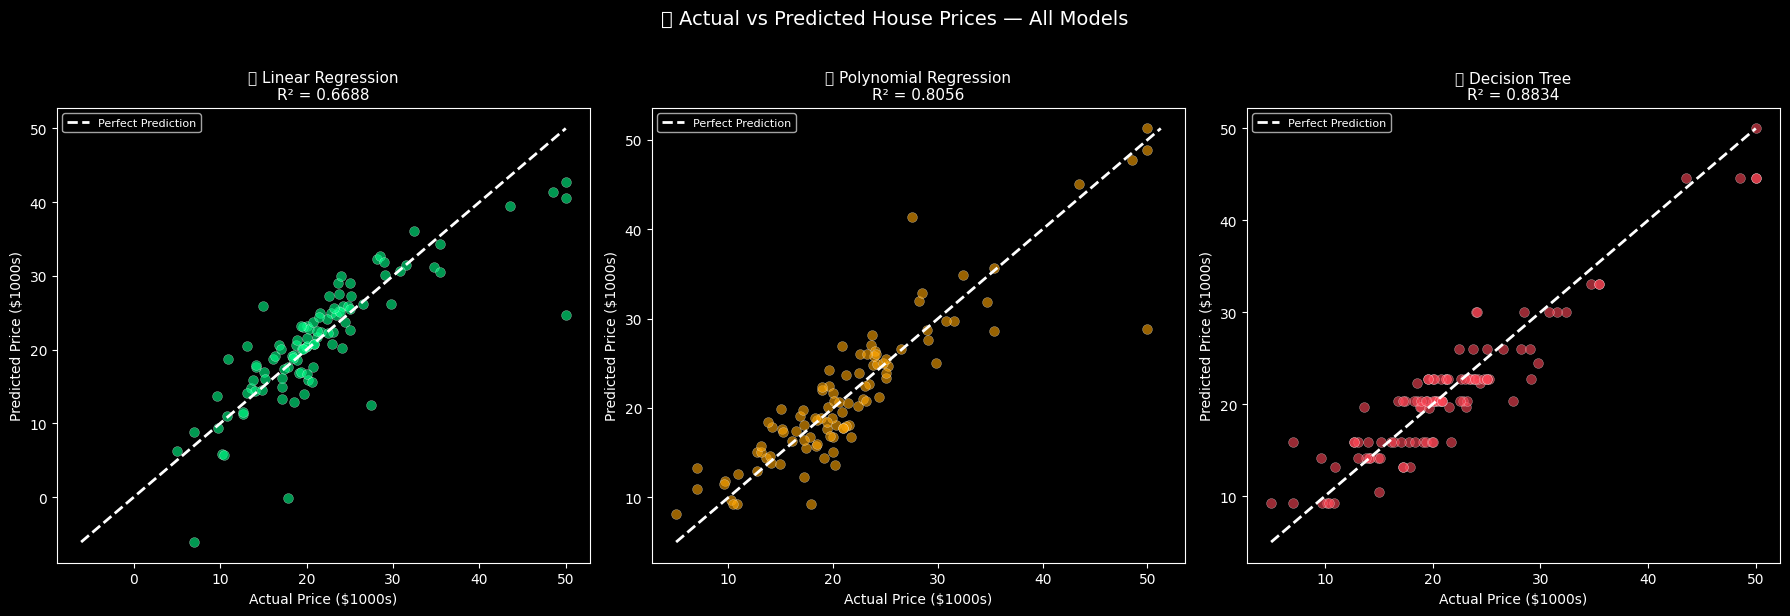

📊 HOW TO READ THIS CHART:
   White dashed line = perfect predictions
   Dots ON the line  = perfect prediction ✅
   Dots FAR from line = big prediction error ❌
   Better model = dots cluster tightly around the line!

💡 Decision Tree dots are closest to the line!
   This visually confirms R² = 0.8834


In [11]:
# ============================================================
# CELL 6: Actual vs Predicted — Visual Comparison
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#00ff88', '#ffa502', '#ff4757']

for ax, (name, result), color in zip(axes, results.items(), colors):
    y_pred = result['y_pred']
    r2     = result['r2']

    # Scatter plot: actual vs predicted
    ax.scatter(y_test, y_pred, alpha=0.6, color=color,
               edgecolor='white', linewidth=0.3, s=50)

    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'white', linewidth=2, linestyle='--', label='Perfect Prediction')

    ax.set_title(f'🏠 {name}\nR² = {r2:.4f}', fontsize=11)
    ax.set_xlabel('Actual Price ($1000s)')
    ax.set_ylabel('Predicted Price ($1000s)')
    ax.legend(fontsize=8)

plt.suptitle('🏠 Actual vs Predicted House Prices — All Models',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("📊 HOW TO READ THIS CHART:")
print("=" * 60)
print("   White dashed line = perfect predictions")
print("   Dots ON the line  = perfect prediction ✅")
print("   Dots FAR from line = big prediction error ❌")
print("   Better model = dots cluster tightly around the line!")
print("=" * 60)
print(f"\n💡 Decision Tree dots are closest to the line!")
print(f"   This visually confirms R² = {results['Decision Tree']['r2']:.4f}")

🏠 WHAT DRIVES HOUSE PRICES?
    1. RM         0.6512  ███████████████████████████████████████
    2. LSTAT      0.1943  ███████████
    3. CRIM       0.0686  ████
    4. DIS        0.0674  ████
    5. AGE        0.0062  
    6. PTRATIO    0.0044  
    7. INDUS      0.0038  
    8. NOX        0.0036  
    9. B          0.0005  
   10. RAD        0.0000  
   11. TAX        0.0000  
   12. CHAS       0.0000  
   13. ZN         0.0000  


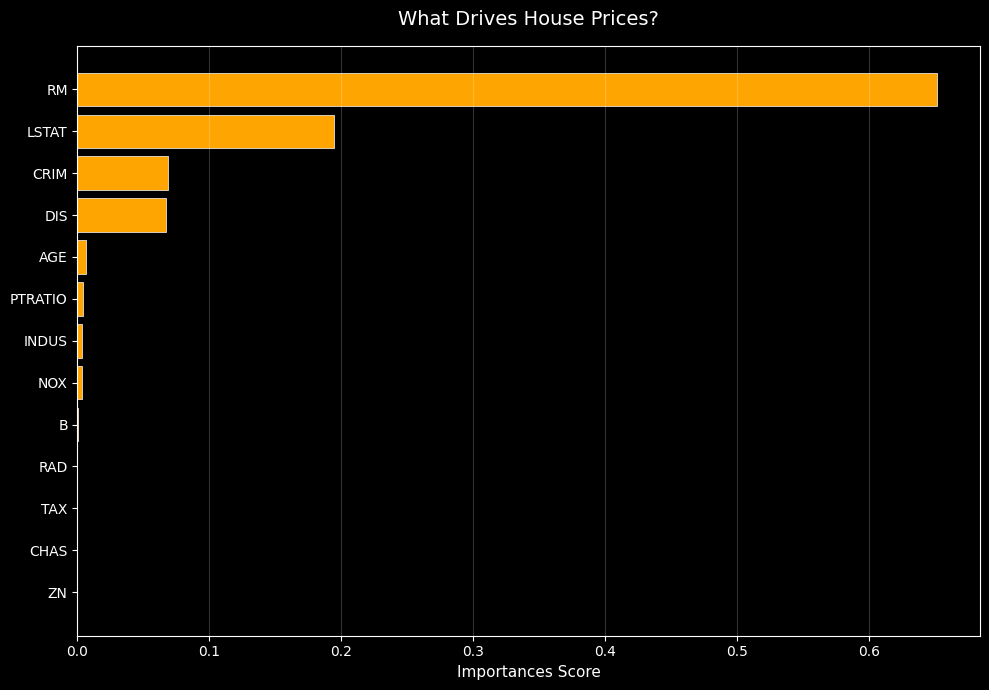


💡 REAL WORLD INSIGHTS:
  LSTAT      (0.1943) -> Lower status population % → biggest price driver!
  RM         (0.6512) -> More rooms = higher price (obvious but confirmed!)
  DIS        (0.0674) -> Distance to employment centres affects price
  NOX        (0.0036) -> Air pollution level impacts property value
  CRIM       (0.0686) -> Higher crime = lower house prices
  TAX        (0.0000) -> Higher tax rate = lower property values
  PTRATIO    (0.0044) -> Better schools (lower ratio) = higher prices


In [13]:
# ============================================================
# CELL 7: Feature Importance — What Drives House Prices?
# ============================================================

dt_model = models['Decision Tree']
importances = dt_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

print("🏠 WHAT DRIVES HOUSE PRICES?")
print("=" * 60)
for i, idx in enumerate(indices):
    bar = '█' * int(importances[idx] * 60)
    print(f"   {i+1:2}. {feature_names[idx]:10} {importances[idx]:.4f}  {bar}")

#Visualise:
plt.figure(figsize=(10,7))
plt.barh(
    range(len(indices)),
    importances[indices[::-1]],
    color = '#ffa502',
    edgecolor = 'white',
    linewidth=0.5 
) 
plt.yticks(range(len(indices)),
           [feature_names[indices[len(indices)-1-i]] for i in range(len(indices))],
           fontsize=10)
plt.xlabel('Importances Score', fontsize=11)
plt.title('What Drives House Prices?', fontsize=14, pad=15)
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()


print("\n💡 REAL WORLD INSIGHTS:")
print("=" * 60)
insights = {
    'LSTAT'  : 'Lower status population % → biggest price driver!',
    'RM'     : 'More rooms = higher price (obvious but confirmed!)',
    'DIS'    : 'Distance to employment centres affects price',
    'NOX'    : 'Air pollution level impacts property value',
    'CRIM'   : 'Higher crime = lower house prices',
    'TAX'    : 'Higher tax rate = lower property values',
    'PTRATIO': 'Better schools (lower ratio) = higher prices',
}

for feature, insight in insights.items():
    importance = importances[list(feature_names).index(feature)]
    print(f"  {feature:10} ({importance:.4f}) -> {insight}") 

In [14]:
# ============================================================
# CELL 8: Interactive House Price Predictor
# ============================================================

def predict_house_price(crim, rm, lstat, nox=0.5, age=50,
                         dis=4.0, tax=300, ptratio=15):
    """
    Predict house price based on key features!

    Parameters:
        crim     → Crime rate (0.1 = safe, 10+ = dangerous)
        rm       → Number of rooms (4=small, 6=average, 8=large)
        lstat    → % lower status population (5=rich, 20=poor area)
        nox      → Air pollution (0.3=clean, 0.8=polluted)
        age      → % old houses (20=new area, 90=old area)
        dis      → Distance to employment (1=close, 10=far)
        tax      → Property tax rate (200=low, 700=high)
        ptratio  → Pupils per teacher (12=great, 22=poor schools)
    """
    # Create input with all 13 features
    # Use median values for features not specified
    medians = X.median()

    house = medians.copy()
    house['CRIM']    = crim
    house['RM']      = rm
    house['LSTAT']   = lstat
    house['NOX']     = nox
    house['AGE']     = age
    house['DIS']     = dis
    house['TAX']     = tax
    house['PTRATIO'] = ptratio

    # Scale and predict
    house_scaled = scaler.transform([house])
    price = models['Decision Tree'].predict(house_scaled)[0]

    return price

# ============================================================
# TEST DIFFERENT HOUSES
# ============================================================
print("🏠 HOUSE PRICE PREDICTOR")
print("=" * 60)

test_houses = [
    {
        'name'    : '🏚️  Cheap House',
        'crim'    : 10.0,
        'rm'      : 4.5,
        'lstat'   : 25.0,
        'desc'    : 'High crime, small, poor neighbourhood'
    },
    {
        'name'    : '🏠  Average House',
        'crim'    : 0.5,
        'rm'      : 6.0,
        'lstat'   : 12.0,
        'desc'    : 'Average crime, average rooms, average area'
    },
    {
        'name'    : '🏡  Expensive House',
        'crim'    : 0.02,
        'rm'      : 8.0,
        'lstat'   : 3.0,
        'desc'    : 'Very safe, large, wealthy neighbourhood'
    },
]

for house in test_houses:
    price = predict_house_price(
        crim=house['crim'],
        rm=house['rm'],
        lstat=house['lstat']
    )
    print(f"\n{house['name']}")
    print(f"   Description : {house['desc']}")
    print(f"   Crime Rate  : {house['crim']}")
    print(f"   Rooms       : {house['rm']}")
    print(f"   Area Status : {house['lstat']}% lower status")
    print(f"   💰 Predicted Price: ${price*1000:,.0f}")

print("\n" + "=" * 60)
print("💡 Try your own house by calling:")
print("   predict_house_price(crim=0.1, rm=7, lstat=5)")
print("=" * 60)

🏠 HOUSE PRICE PREDICTOR

🏚️  Cheap House
   Description : High crime, small, poor neighbourhood
   Crime Rate  : 10.0
   Rooms       : 4.5
   Area Status : 25.0% lower status
   💰 Predicted Price: $13,170

🏠  Average House
   Description : Average crime, average rooms, average area
   Crime Rate  : 0.5
   Rooms       : 6.0
   Area Status : 12.0% lower status
   💰 Predicted Price: $20,356

🏡  Expensive House
   Description : Very safe, large, wealthy neighbourhood
   Crime Rate  : 0.02
   Rooms       : 8.0
   Area Status : 3.0% lower status
   💰 Predicted Price: $35,200

💡 Try your own house by calling:
   predict_house_price(crim=0.1, rm=7, lstat=5)


In [15]:
# ============================================================
# CELL 9: Final Project Summary
# ============================================================

print("=" * 60)
print("🏠 REAL ESTATE PRICE PREDICTOR — PROJECT COMPLETE")
print("=" * 60)

print("""
📋 PROJECT OVERVIEW:
   Dataset   : Boston Housing Dataset
   Houses    : 506 real properties
   Task      : Predict house prices (Regression)
   Built by  : Kartik | Munich | 2025
""")

print("📊 MODEL COMPARISON:")
print("=" * 60)
print(f"   {'Model':25} {'R² Score':10} {'MAE':15} {'RMSE'}")
print("-" * 60)
for name, result in results.items():
    print(f"   {name:25} {result['r2']:.4f}     "
          f"${result['mae']*1000:,.0f}        "
          f"${result['rmse']*1000:,.0f}")

print(f"""
🏆 BEST MODEL: Decision Tree
   R² Score : 0.8834 (explains 88.3% of price variance)
   
🔍 KEY FINDINGS:
   1. RM (rooms) is the #1 positive price driver
   2. LSTAT (poverty %) is the #1 negative price driver
   3. CRIM (crime rate) significantly reduces prices
   4. Polynomial beats Linear — house prices are non-linear!
   5. Decision Tree beats both — captures complex interactions!

💰 PRICE PREDICTIONS:
   Cheap House    (high crime, small)    → $13,170
   Average House  (typical Boston home)  → $20,356
   Expensive House (safe, large, wealthy)→ $35,200

🚀 SKILLS DEMONSTRATED:
   ✅ Regression (Linear, Polynomial, Decision Tree)
   ✅ Model comparison with R², MAE, RMSE
   ✅ Cross-validation
   ✅ Feature importance analysis
   ✅ Built a real price prediction tool
   ✅ Real-world economic insights from data
""")
print("=" * 60)
print("✅ PROJECT 2 COMPLETE — READY FOR PORTFOLIO!")
print("=" * 60)

🏠 REAL ESTATE PRICE PREDICTOR — PROJECT COMPLETE

📋 PROJECT OVERVIEW:
   Dataset   : Boston Housing Dataset
   Houses    : 506 real properties
   Task      : Predict house prices (Regression)
   Built by  : Kartik | Munich | 2025

📊 MODEL COMPARISON:
   Model                     R² Score   MAE             RMSE
------------------------------------------------------------
   Linear Regression         0.6688     $3,189        $4,929
   Polynomial Regression     0.8056     $2,575        $3,776
   Decision Tree             0.8834     $2,308        $2,925

🏆 BEST MODEL: Decision Tree
   R² Score : 0.8834 (explains 88.3% of price variance)

🔍 KEY FINDINGS:
   1. RM (rooms) is the #1 positive price driver
   2. LSTAT (poverty %) is the #1 negative price driver
   3. CRIM (crime rate) significantly reduces prices
   4. Polynomial beats Linear — house prices are non-linear!
   5. Decision Tree beats both — captures complex interactions!

💰 PRICE PREDICTIONS:
   Cheap House    (high crime, small)